Diffusion models are generative models that create new data (like images). At a high level, diffusion models start with pure noise (like a static TV screen) and gradually remove noise step by step until a clear image forms, guided by your text prompt. This process makes them powerful for creative tasks like AI art, image editing, and even video generation. So, if you want to learn AI Image Generation, this article is for you. In this article, I’ll explain AI Image Generation using Diffusion Models with Python.

First, let’s get the tools we need. We’ll use Hugging Face Diffusers, PyTorch, and a few utility libraries. Here’s how to install them if you are not using Google Colab:

pip install diffusers transformers accelerate torch torchvision safetensors

Now, let’s prepare the pipeline for AI Image Generation using Diffusion Models. We’ll write code in a way that works on a GPU, Apple M1/M2 chip, or just a CPU:

In [4]:
import torch
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id, torch_dtype=torch.float16 if device=="cuda" else torch.float32
)

pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)

if device == "cuda":
    pipe = pipe.to(device)
    pipe.enable_attention_slicing()
else:
    pipe.to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Here’s what’s happening here:

    1.We load Stable Diffusion v1.5, a widely used model for text-to-image.

    2.We detect your hardware, such as CUDA (NVIDIA GPU), MPS (Apple Silicon), or CPU.

    3.The Euler Ancestral sampler is set, a fast and high-quality sampling method.

    4.On the GPU, we enable attention slicing to save memory.
 If you’re on CPU, it will still work, just slower.

Now comes the prompting part. It means telling the model what to generate:

In [7]:
prompt = "A majestic Bengal tiger standing on a rock in a lush green Indian forest, photorealistic, detailed fur, sunlight filtering through trees, high-resolution, cinematic lighting"
negative_prompt = "blurry, low quality, deformed, extra limbs, text, watermark, poorly drawn, unnatural colors, overexposed"

The prompt here means what you want in the image. And the negative_prompt means what you don’t wish to (helps avoid weird results). Always be descriptive! Adding details like lighting, style, or lens type can significantly enhance image quality.

Now, let’s create the image with some key parameters:

In [8]:
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,   # 20–35 is a good range
    guidance_scale=7.5,       # 5–9 usually
    height=512,
    width=512,
    generator=torch.Generator(device=device).manual_seed(42)
).images[0]

image.save("generated_image.png")

  0%|          | 0/30 [00:00<?, ?it/s]

Here are some key parameters we used:

1.num_inference_steps: how many steps the model takes to denoise the image. More steps = more detail, but slower.

2.guidance_scale: how strongly the model follows your text prompt. Lower (3–5) = more creative, sometimes unexpected.

3.manual_seed(42): ensures reproducibility. Same seed + prompt = same image. Change the seed for fresh variations.

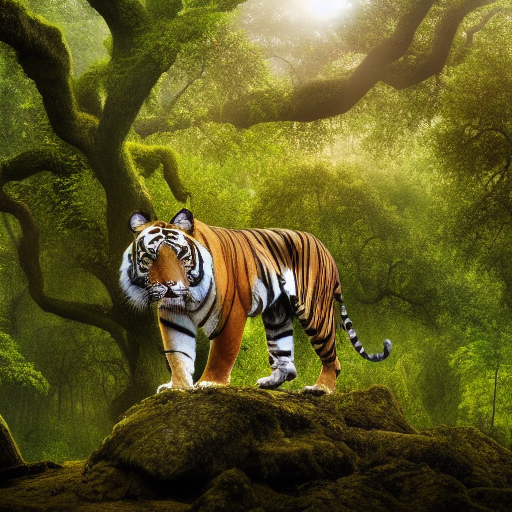

In [14]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\santh\Downloads\generated_image.png"))